In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb
from string import ascii_letters

In [2]:
from tqdm import tqdm

In [3]:
%config InlineBackend.figure_format = "retina"

## Q.1

In [4]:
np.random.seed(314)
N = 2
n_days = 365
n_sims = 200_000
S = np.random.choice(n_days, (n_sims, 2))
S[:5]

array([[  8, 109],
       [201, 342],
       [ 42, 240],
       [  7, 226],
       [120, 342]])

In [5]:
# Probability of any two of them sharing the same birthday
(1 / 365)

0.0027397260273972603

In [6]:
pr_emp = (S[:, 0] == S[:, 1]).mean()
format(pr_emp, "0.5f")

'0.00277'

### N = 3

In [7]:
N = 100
n_days = 365
days = np.arange(n_days)
n_sims = 500_000


In [ ]:
N_values = np.arange(1, 51)
pr_array = np.zeros(50)
pr_cum = np.zeros(50)
for i, N in tqdm(enumerate(N_values)):
    np.random.seed(314)
    S = np.random.choice(n_days, (n_sims, N))
    pr_emp = ((S[..., None] == days[None, None, :]).sum(axis=1) == 2).any(axis=1).mean()
    pr_array[i] = pr_emp

In [ ]:
plt.plot(N_values, pr_array)
plt.grid(alpha=0.3)

In [ ]:
pd.DataFrame({
    "N": N_values,
    "pr": pr_array,
})

## Teoretical

In [ ]:
N = 3

def pr(N):
    n_combinations = comb(N, 2)
    n_terms = np.arange(1, n_combinations)
    comb_terms = comb(n_combinations, n_terms)
    pm_terms = (-1) ** (n_terms - 1) # plus or minus terms
    return (comb_terms * np.power(1 / 365, n_terms) * pm_terms).sum()

In [ ]:
N_values = np.arange(2, 51)
pr_th = np.array([pr(n) for n in N_values])
plt.plot(N_values, pr_th)
plt.plot(N_values, pr_array[1:], c="black", linestyle="--")
plt.xlabel("$N$")
plt.ylabel("Pr")
plt.grid(alpha=0.3)

In [ ]:
pr_th

In [ ]:
def pr_complement(N):
    """
    Probability that they all share the same birthday
    """
    num_comb = comb(N, 2)
    return (364 / 365) ** (num_comb)

In [ ]:
N_values = np.arange(2, 51)
pr_th = np.array([pr(n) for n in N_values])
plt.plot(N_values, pr_th, label="union")
plt.plot(N_values, 1 - pr_complement(N_values), label="complement")
plt.plot(N_values, pr_array[1:], c="black", linestyle="--", label="empirical")
plt.xlabel("$N$")
plt.ylabel("Pr")
plt.legend()
plt.grid(alpha=0.3)

In [ ]:
1/2 + np.log2(2 * )

In [ ]:
1/ 2 + np.sqrt(2 * np.log2(365 / 364) + 4)

In [ ]:
np.log2(1/2)

In [ ]:
np.sqrt(2 * np.log2(365 / 364) + 1/4)

In [ ]:
-1 / np.log2(364 / 365)

In [ ]:
1 / np.log2(365 / 364)

In [ ]:
C = 1 / np.log2(365 / 364)
threshold = 1/2 + np.sqrt(2 * C + 1/4)
threshold = threshold.round()
threshold

In [ ]:
N_values = np.arange(2, 51)
pr_th = np.array([pr(n) for n in N_values])
plt.plot(N_values, pr_th, label="union")
plt.plot(N_values, 1 - pr_complement(N_values), label="complement")
plt.plot(N_values, pr_array[1:], c="black", linestyle="--", label="empirical")
plt.axvline(x=threshold, c="black")
plt.axhline(y=0.5, c="black")
plt.xlabel("$N$")
plt.ylabel("Pr")
plt.legend()
plt.grid(alpha=0.3)

## Birthday line

At a movie theater, a whimsical manager announces that she will give a free ticket to the first person in line whose birthday is the same as someone who has already bought a ticket. You are given the opportunity to choose any position in line. Assuming that you don't know anyone else's birthday and all birthdays are distributed randomly throughout the year, **what position in line gives you the largest chance of getting a free ticket?**

**A:** Let $N \geq 2$ be your position in line
and
let $B_i$ be the birtday for the $i$-th person. Here $i=1,\ldots,N$.

The probability that you share a birthday with the first person in line $B_N = B_1$
and the people before you do not share a birthday among themselves $B_i \neq B_j$ is

$$
\begin{aligned}
    &{\rm Pr}\Big([B_N=B_1] \cap [B1 \neq B2] \cap \ldots \cap [B_{N-1} \neq B_{N-2}]\Big)\\
    &={\rm Pr}\Big([B_N=B_1]\Big) {\rm Pr}\Big([B1 \neq B2] \cap \ldots \cap [B_{N-1} \neq B_{N-2}]\Big)\\
    &={\rm Pr}\Big([B_N=B_1]\Big) {\rm Pr}\Big([B1 \neq B2]\Big)^{{N-1}\choose{2}}\\\
    &= \frac{1}{365}\left(\frac{364}{365}\right)^{{N-1}\choose{2}}
\end{aligned}
$$

where the equality follows from independence.

Next, the probability that you share a birthday with any of the $N-1$ people in line is
$$
    f(N) = \frac{N-1}{365}\left(\frac{364}{365}\right)^{{N-1}\choose{2}}
$$

We want to find $N_*$ such that
$$
    N_* = \arg\max_N f(N).
$$

To do this, take logs

$$
    \log f(N) = \log(N-1) - \log(365) + {{N-1}\choose 2}\log\left(\frac{364}{365}\right)
$$

Taking derivivative and setting to zero, we find that

$$
    N = 1 + \sqrt{\log(\tfrac{365}{364})^{-1}} \approx 20
$$

In [46]:
def proba(N):
    return (N - 1) / 365 * np.power(364 / 365, comb(N-1, 2))

np.float64(20.091877104575165)

In [51]:
C = np.log(364/365)
N_max = np.sqrt(-1/C) + 1
N_max

np.float64(20.091877104575165)

In [ ]:
N = np.arange(2, 80)
plt.plot(N, proba(N))
plt.axvline(x=N_max, c="black")
plt.grid(alpha=0.3)

## Dice

In [58]:
20 / 6 ** 3

0.09259259259259259

In [56]:
total_sum = 0
for a1 in range(1, 5):
    for a2 in range(a1 + 1, 6):
        for a3 in range(a2 + 1, 7):
            total_sum += 1
            print(a1, a2, a3)
total_sum

1 2 3
1 2 4
1 2 5
1 2 6
1 3 4
1 3 5
1 3 6
1 4 5
1 4 6
1 5 6
2 3 4
2 3 5
2 3 6
2 4 5
2 4 6
2 5 6
3 4 5
3 4 6
3 5 6
4 5 6


20

## Monty hall

In [ ]:
def simulation():
    door_values = 1.0 * (np.random.choice([0,1,2], 3, replace=False) >= 1)
    random_action = jax.random.choice(3)

## Wise men

In [224]:
n = 50
switch = 0
has_flipped = np.zeros(n)

ix_target = 0 # index of the wiseman who counts

n_flips = 1
n_flips_count = 0
count_hist = []
ix_hist = []

# np.random.seed(3141)
while n_flips_count <= (n - 1):
    ix = np.random.choice(n)

    if (switch == 0) and (has_flipped[ix] == 0):
        switch = 1
        has_flipped[ix] = 1
        
    elif (switch == 1) and (ix == ix_target):
        n_flips_count += 1
        switch = 0

    count_hist.append(n_flips_count)
    ix_hist.append(ix)

count

count_hist = np.array(count_hist)
ix_hist = np.array(ix_hist)

Text(0, 0.5, 'times called')

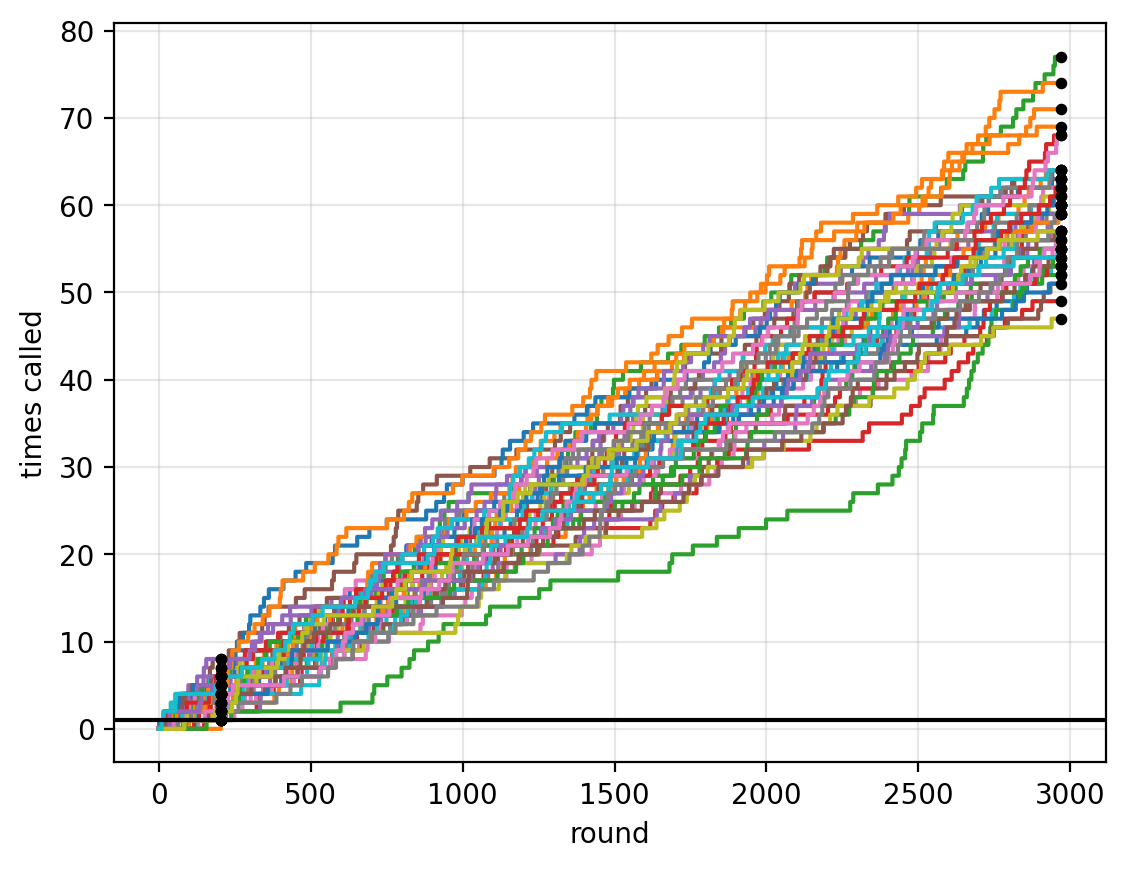

In [230]:
ix_skip = np.all(ix_ohe_hist >= 1, axis=1).argmax()

ix_ohe_hist = jax.nn.one_hot(ix_hist, n).cumsum(axis=0)

plt.step(np.arange(len(ix_ohe_hist)), ix_ohe_hist, where="post")
# plt.axhline(y=n, c="black")
plt.axhline(y=1, c="black")
plt.scatter(np.ones(n) * len(ix_ohe_hist) - 1, ix_ohe_hist[-1], c="black", s=10, zorder=4)
plt.scatter(np.ones(n) * ix_skip, ix_ohe_hist[ix_skip], c="black", zorder=4, s=10)
plt.grid(alpha=0.3)
plt.xlabel("round")
plt.ylabel("times called")

## Linear regression

In [245]:
np.random.seed(314)
x = np.random.uniform(-2, 2, 100)
err = np.random.normal(100)
y = 3 * x + err 

In [246]:
x.T @ y / (x.T @ x)

np.float64(2.830947154258893)

In [289]:
np.random.seed(314)
x1, x2 = np.random.uniform(-2, 2, (2, 100))
err = np.random.normal(100)
y = 3 * x1 - 2 * x2 + err * 0.1

In [290]:
X = np.c_[x1, x2]
np.linalg.solve(X.T @ X, X.T @ y)

array([ 2.96518504, -1.83075274])

## Russian roulette

In [298]:
comb(5, 5) / comb(5, 5)

np.float64(1.0)

In [301]:
(comb(6, 5) - 1) / comb(6, 5)

np.float64(0.8333333333333334)

In [305]:
(comb(5, 4) - comb(4, 4)) / comb(5, 4)

np.float64(0.8)

In [306]:
(comb(6,4) - 2) / comb(6,4)

np.float64(0.8666666666666667)

In [309]:
n_bullets = 3

In [313]:
(comb(5, n_bullets) - 3)

np.float64(7.0)

In [316]:
comb(5, 2)

np.float64(10.0)

In [448]:
n_bullets = 4

In [449]:
# Spin
elements = range(6)
for c in combinations(elements, n_bullets):
    elements = ["x" if x in c else "o" for x in range(6)]
    print(" ".join(elements))

x x x x o o
x x x o x o
x x x o o x
x x o x x o
x x o x o x
x x o o x x
x o x x x o
x o x x o x
x o x o x x
x o o x x x
o x x x x o
o x x x o x
o x x o x x
o x o x x x
o o x x x x


In [450]:
nb = comb(6, n_bullets) - comb(5, n_bullets)
n_total = comb(6, n_bullets)

nb / n_total

np.float64(0.6666666666666666)

In [451]:
# Don't spin
elements = range(5)
for c in combinations(elements, n_bullets):
    elements = ["x" if x in c else "o" for x in range(5)]
    print(" ".join(elements))

x x x x o
x x x o x
x x o x x
x o x x x
o x x x x


#### Elements

In [467]:
for n_bullets in range(5, 1, -1):
    n_total = comb(6, n_bullets)
    nb = comb(6, n_bullets) - comb(5, n_bullets)
    proba_spin = nb / n_total

    n_total = comb(5, n_bullets)
    nb = comb(5, n_bullets) - comb(4, n_bullets)
    proba_not_spin = nb / n_total

    print(f"{n_bullets=}| spin={proba_spin:0.2%} | not-spin={proba_not_spin:0.2%}")

n_bullets=5| spin=83.33% | not-spin=100.00%
n_bullets=4| spin=66.67% | not-spin=80.00%
n_bullets=3| spin=50.00% | not-spin=60.00%
n_bullets=2| spin=33.33% | not-spin=40.00%


**two consecutive bullets**

In [ ]:
o o o o x x

In [ ]:
2 / 6 # spinning barrel
2 / 5 

In [490]:
1/4 # no spin

0.25

In [491]:
1/3 # spin

0.3333333333333333

In [547]:
nsub = 4 * comb(48, 12) * 3 * comb(36, 12) * 2 * comb(24, 12) * comb(12, 12)
nsub

5659423235091422706737318400

In [548]:
ntot = comb(52, 13) * comb(52 - 13, 13) * comb(52 - 2 * 13, 13) * comb(52 - 3 * 13, 13)
ntot

53644737765488792839237440000

In [549]:
nsub / ntot

0.10549819927971188

In [550]:
1 * 39 / 51 * 26 / 50 * 13 / 49

0.10549819927971188

In [553]:
52 - 13

39

In [ ]:
Pr(ace in any pile) = 52 / 52 = 1

Pr(ace in any second pile) = 39 / 51

Pr(ace in any third pile) = 26 / 50

Pr(ace in any fourth pile) = 13 / 49

In [863]:
N = 10
p = 0.5
q = 1 - p
i_init = 1

n_trials = 100
n_sims = 1_000

trials = np.zeros(n_trials)
for t in range(n_trials):
    results = np.zeros(n_sims)
    for n in range(n_sims):
        i = i_init
        while i not in [0, N]:
            step = np.random.choice([-1, 1], p=[p, 1-p])
            i += step
        results[n] = i

    trials[t]= (results == N).mean()

In [864]:
np.quantile(trials, 0.25)

np.float64(0.094)

In [865]:
np.quantile(trials, 0.75)

np.float64(0.105)

In [866]:
def proba_win(n: int, N:int, p:float) -> float:
    if p == 1/2:
        proba = n / N
    else:
        q = 1 - p
        r = p / q
        proba = (1 - r ** n) / (1 - r ** N)

    return proba

In [867]:
proba_win(n=1, N=10, p=p)

0.1

In [898]:
2 * 3 ** 2 + 2 ** 2 * 3 + 2 ** 3 + 2 * 3 + 2 ** 2 + 2 

50

In [874]:
factorial(5)

120

In [899]:
(2 * 3 ** 2 + 2 ** 2 * 3 + 2 ** 3 + 2 * 3 + 2 ** 2 + 2) / factorial(5)

0.4166666666666667

In [ ]:
1 1 1 2
1 1 2 2
1 1 2 3
1 2 2 2
1 2 2 3
1 2 3 3

In [879]:
V = np.array([
    [1, 1, 1, 2],
    [1, 1, 2, 2],
    [1, 1, 2, 3],
    [1, 2, 2, 2],
    [1, 2, 2, 3],
    [1, 2, 3, 3]
])

In [896]:
V.prod(axis=1).sum()

np.int64(50)

In [893]:
V.prod(axis=1).sum() / factorial(5)

np.float64(0.4166666666666667)

1 0 x x x

In [900]:
comb(3, 2)

3

In [1155]:
i = 100
Ti = 50

In [1156]:
i, Ti = 6, 3

In [1159]:
comb(i - 2, Ti - 1) * 6 / factorial(i - 1)

0.300

## Basketball

In [1707]:
n_sims = 10_000

i = 100
Ti = 50

probas_hist = []
scores_hist = []
n_count = 0
np.random.seed(314)
for n in range(n_sims):
    scores = [1, 0]
    probas = [1, 1/2]
    for r in range(i - 2):
        pr = sum(scores) / len(scores)
        score = np.random.binomial(1, pr)
        scores.append(score)
        probas.append(pr)
    
    probas = np.array(probas)
    scores = np.array(scores)
    if sum(scores) == Ti:
        n_count += 1
        probas_hist.append(probas)
        scores_hist.append(scores)

probas_hist = np.array(probas_hist)
scores_hist = np.array(scores_hist)

In [1708]:
Pr = (-1) ** (1 - scores_hist) * probas_hist + (1 - scores_hist)

Pr[:, 2:].prod(axis=1)

array([3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31,
       3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31,
       3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31,
       3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31,
       3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31,
       3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31,
       3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31,
       3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31,
       3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31,
       3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31,
       3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31,
       3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31,
       3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31,
       3.965e-31, 3.965e-31, 3.965e-31, 3.965e-31, 

In [1713]:
p = factorial(Ti - 1) * factorial(i - Ti - 1) / factorial(i - 1)
format(p, "0.4")

'3.965e-31'

In [1714]:
comb(i-2, Ti-1) *  p

0.010

In [1711]:
# Empirical
n_count / n_sims

0.011

In [1712]:
from sympy import symbols

In [1706]:
n, N = symbols("n N")

vals = [1, 1, 0, 1, 0, 1]
v1 = 1
for v in vals:
    if v == 1:
        v1 *= n / N
        n = n + 1
    else:
        v1 *= 1 - n / N
        
    N = N + 1

v1.simplify()

n*(N - n)*(n + 1)*(n + 2)*(n + 3)*(N - n + 1)/(N*(N + 1)*(N + 2)*(N + 3)*(N + 4)*(N + 5))

In [1680]:
n, N = symbols("n N")

vals = [1, 1, 0, 0, 1, 1]
v2 = 1
for v in vals:
    if v == 1:
        v2 *= n / N
        n = n + 1
    else:
        v2 *= (1 - n / N)
        
    N = N + 1

v2.simplify()

n*(N - n)*(n + 1)*(n + 2)*(n + 3)*(N - n + 1)/(N*(N + 1)*(N + 2)*(N + 3)*(N + 4)*(N + 5))

In [1681]:
v1.simplify()

n*(N - n)*(n + 1)*(n + 2)*(n + 3)*(N - n + 1)/(N*(N + 1)*(N + 2)*(N + 3)*(N + 4)*(N + 5))

In [1682]:
n, N = symbols("n, N")

In [1683]:
v1.simplify().subs({N: 2, n: 1})

1/105

In [1684]:
v2.simplify().subs({n: 1, N:2})

1/105

In [1685]:
perm(4) * perm(2) / factorial(7)

0.010

In [1686]:
1/105

0.010

## Fair proba from unfair coin

In [1733]:
x = 0.3
N = 10_000

target = [0, 1]
U = [(0,1), (1, 0)]

count_all = 0
count_target = 0
for n in range(N):
    c1, c2 = np.random.binomial(1, x, size=2)
    c1 = c1.item()
    c2 = c2.item()
    if (c1, c2) in U:
        count_all += 1
        if [c1, c2] == target:
            count_target += 1

count_target / count_all

0.503

## Probability of coins

In [2]:
import numpy as np

In [110]:
from copy import deepcopy

In [133]:
count_base = {
    "red": 2,
    "blue": 1,
    "green": 1
}

colors = list(count)
hits = 0
hits_other = 0 # Test another hypothesis
n_sims = 10_000
for n in range(n_sims):
    count = deepcopy(count_base)
    while count["red"] != 0:
        choice = np.random.choice([c for c in colors if count[c] > 0])
        count[choice] -= 1
        
    hits += (count["blue"] > 0) & (count["green"] > 0)
    hits_other += (count["blue"] == 0) | (count["green"] == 0)
    count

hits / n_sims

0.1086

In [ ]:
F1, F2, F3

In [ ]:
Pr(R=0 n [G = 0] u [B = 0])

In [ ]:
Pr(A U B) = Pr(A) + Pr(B) - P(A n B)

In [ ]:
Pr(R=0, G=0) + Pr(R=0, B=0) - Pr(R=0, G=0, B=0)

In [ ]:
Pr(R=0) Pr(G=0 | R=0) + Pr(R=0) Pr(B=0 | R=0)

In [145]:
2 / 4 * 1 / 3 * ( 1 / 2 + 1 / 2 ) 

0.16666666666666666

In [146]:
2 / 4 * 1 / 3 * 1/2

0.08333333333333333

## Coin toss game

In [216]:
def coin_game(n_max=10_000):
    sequence = ""
    for i in range(n_max):
        player = i % 2 # 0: A, 1: B
        sequence += np.random.choice(["H", "T"])
    
        if (sequence[-2:] == "HT"):
            break
    return player, sequence

In [234]:
n_simulations = 10_000

counts = {0:0, 1:0}
for n in range(n_simulations):
    player, sequence = coin_game()
    counts[player] += 1

In [235]:
pd.Series(counts) / n_simulations

0    0.4448
1    0.5552
dtype: float64

## 1/4

## Prime numbers

In [237]:
numbers = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53]

In [260]:
count = 0
n_sims = 10_000

for _ in range(n_sims):
    subset = np.random.choice(numbers, 4, replace=False)
    count += subset.sum() % 2 == 0

In [261]:
count / n_sims

np.float64(0.7439)

In [264]:
3/ 4 # Pr(odd) = (15 / 16) * (14 / 15) * (13 / 14) * (12 / 13)

0.75

In [268]:
comb(15, 4) / comb(16, 4)

0.75

### Meeting probability

In [296]:
n_sims = 10_000
count = 0
for n in range(n_sims):
    arrival_times = np.random.random(2) * 60
    meet1 = arrival_times[0] < arrival_times[1] < arrival_times[0] + 5
    meet2 = arrival_times[1] < arrival_times[0] < arrival_times[1] + 5
    count += meet1 or meet2

count / n_sims

np.float64(0.1584)

In [297]:
1/6

0.16666666666666666

In [298]:
23 / 144

0.1597222222222222

In [299]:
60 ** 2

3600

In [302]:
(60 + 55) * (60 - 55)

575

## Property of Poisson process

In [351]:
np.random.seed(314)
S = np.random.poisson(lam=0.1, size=10 * 200).reshape(-1, 10)
S[:20]

array([[1, 0, 0, 1, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 2, 1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [357]:
# Probability of a bus appearing during a 10min slot
(S >= 1).any(axis=1).mean()

np.float64(0.59)

```
E[waiting time] = E[time to next bus]

Pr(ttnb = 10min)
```

In [360]:
from scipy.stats import poisson

In [378]:
lam = 3 # number of calls in a minute
X = poisson(lam)
X.pmf(np.arange(1, 5)).sum() # Probability of observing between 1 and 5 calls

np.float64(0.7654761761559081)

In [379]:
(1 - X.cdf(4)) + X.cdf(0) # Probability of observing 0 or more than 5 calls

np.float64(0.23452382384409176)